# SARIMAX & Gradient Boosting Modelling for NSW Electricity Demand Forecasting

## 1. Objective

The aim of this notebook is to develop and evaluate forecasting models for NSW electricity demand using historical demand and selected exogenous variables. A SARIMAX model is used as a statistical baseline, and a Gradient Boosting model is introduced as a machine learning approach.

Models are evaluated over multiple forecasting horizons using mean squared error (MSE) and root mean squared error (RMSE). Comparison with the provided forecast is limited to the 48-step horizon, where it is available, while longer horizons are used to compare model performance within the project.

## 2. Import libraries

This section imports the Python libraries required for data handling, visualisation, time series modelling, and model evaluation.

- `pandas` and `numpy` are used for data manipulation
- `matplotlib` is used for visualisation
- `statsmodels` provides the SARIMAX model
- `sklearn` is used to calculate evaluation metrics such as MSE and RMSE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

## 3. Load data

In this section, the preprocessed training, validation, and test datasets are loaded. These datasets were generated during the preprocessing stage to ensure consistency across all models in the project.

Using pre-split datasets allows for a fair comparison between models and avoids data leakage. The data is recorded at 30-minute intervals, which informs the temporal structure used in the forecasting models.

The model will be trained on the training set and evaluated on the validation and test sets.

In [2]:
# Load datasets from project root (notebook in src/)
from pathlib import Path
root = Path.cwd().resolve().parents[0]  # project root when running from src/

train_path = root / 'data' / 'NSW' / 'train.csv'
validation_path = root / 'data' / 'NSW' / 'validation.csv'
test_path = root / 'data' / 'NSW' / 'test.csv'


train = pd.read_csv(train_path, parse_dates=['DATETIME'], index_col='DATETIME')
validation = pd.read_csv(validation_path, parse_dates=['DATETIME'], index_col='DATETIME')
test = pd.read_csv(test_path, parse_dates=['DATETIME'], index_col='DATETIME')

# Quick check
print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (112651, 6)
Validation shape: (37550, 6)
Test shape: (37552, 6)


,TOTALDEMAND,TEMPERATURE,FORECASTDEMAND,demand_1_day_ago,demand_1_week_ago,demand_1_year_ago
DATETIME,,,,,,
2010-07-02 12:00:00,11409.84,11.0,10385.83,10035.63,9766.12,8038.00
2010-07-02 12:30:00,11276.77,11.5,10537.08,9686.17,9521.15,7809.31
2010-07-02 13:00:00,11208.75,11.6,10359.19,9513.42,9318.45,7483.69
2010-07-02 13:30:00,11184.47,11.8,10247.97,9255.59,9108.57,7117.23
2010-07-02 14:00:00,11141.20,12.0,10119.70,9019.79,8863.47,6812.03


## 4. Data inspection

Before fitting the model, the structure and properties of the dataset are examined. 
This includes checking the data types, confirming the presence of key variables, and ensuring that the datetime index is correctly formatted.

Understanding the dataset at this stage helps identify any potential issues and ensures that the forecasting models are applied appropriately.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 112651 entries, 2010-07-02 12:00:00 to 2016-12-04 09:00:00
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   TOTALDEMAND        112651 non-null  float64
 1   TEMPERATURE        112651 non-null  float64
 2   FORECASTDEMAND     112651 non-null  float64
 3   demand_1_day_ago   112651 non-null  float64
 4   demand_1_week_ago  112651 non-null  float64
 5   demand_1_year_ago  112651 non-null  float64
dtypes: float64(6)
memory usage: 6.0 MB


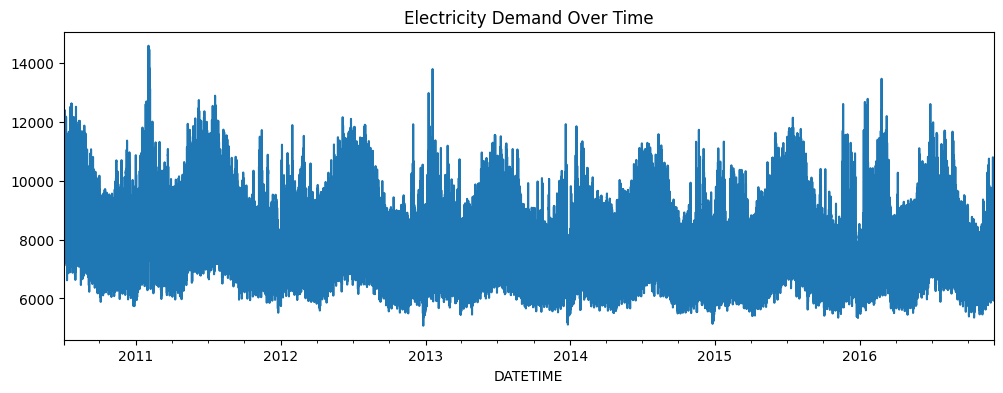

In [3]:
# Check data types and structure
train.info()

# Summary statistics
train.describe()

# Check for missing values
train.isna().sum()

# Quick visual of target variable
train['TOTALDEMAND'].plot(figsize=(12,4), title='Electricity Demand Over Time')
plt.show()

The time series plot shows clear periodic patterns, including strong daily cycles and longer-term seasonal variation. This indicates that electricity demand is influenced by recurring temporal patterns, making it suitable for time series forecasting approaches.

Additionally, the data is recorded at 30-minute intervals, which informs the choice of a seasonal period of 48 for models that incorporate seasonality.

In [4]:
# Set 30-minute frequency for time series modelling
train = train.sort_index()
validation = validation.sort_index()
test = test.sort_index()

train.index.freq = '30min'
validation.index.freq = '30min'
test.index.freq = '30min'
train.index.to_series().diff().value_counts().head()

DATETIME
0 days 00:30:00    112650
Name: count, dtype: int64

## 5. Define target and exogenous variables

The target variable for the models is total electricity demand (`TOTALDEMAND`).

Two exogenous variables are included: temperature and forecast demand. Temperature captures the impact of weather conditions on electricity usage, while the provided forecast demand represents an external benchmark prediction.

Lagged demand variables are not included in the SARIMAX model, as it captures temporal dependencies internally through its autoregressive structure. However, lagged features are used in the Gradient Boosting model to provide historical context, as tree-based models do not inherently account for time dependencies.

Including temperature and forecast demand allows the models to incorporate both external influences and baseline demand expectations while maintaining a valid forecasting setup.

In [5]:
# Target variable
y_train = train['TOTALDEMAND']
y_val = validation['TOTALDEMAND']
y_test = test['TOTALDEMAND']

# Exogenous variables
exog_vars = ['TEMPERATURE', 'FORECASTDEMAND']

X_train = train[exog_vars]
X_val = validation[exog_vars]
X_test = test[exog_vars]
print(X_train.head())

# Clean and align training data
combined_train = pd.concat([y_train, X_train], axis=1).dropna()

y_train_clean = combined_train['TOTALDEMAND']
X_train_clean = combined_train[['TEMPERATURE', 'FORECASTDEMAND']]

# Forecast horizons
horizons = [48, 336, 720]
window_start = 100


                     TEMPERATURE  FORECASTDEMAND
DATETIME                                        
2010-07-02 12:00:00         11.0        10385.83
2010-07-02 12:30:00         11.5        10537.08
2010-07-02 13:00:00         11.6        10359.19
2010-07-02 13:30:00         11.8        10247.97
2010-07-02 14:00:00         12.0        10119.70


## 6. Helper functions

To keep the notebook concise and consistent, helper functions are defined for forecasting, metric calculation, and visualisation. 
This avoids unnecessary repetition and ensures that each model is evaluated using the same process.

In [6]:
def run_forecast(model_results, X_test, y_test, window_start, horizon):
    """
    Generate forecast and calculate error metrics for a given horizon.
    """
    y_actual = y_test.iloc[window_start:window_start + horizon]
    X_exog = X_test.iloc[window_start:window_start + horizon]

    forecast = model_results.get_forecast(
        steps=horizon,
        exog=X_exog
    )

    y_pred = forecast.predicted_mean

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mse = mean_squared_error(y_actual, y_pred)

    return y_actual, y_pred, rmse, mse


def plot_forecast(y_actual, y_pred, provided_forecast, horizon, title):
    plt.figure(figsize=(10, 5))

    plt.plot(range(horizon), y_actual.values, label='Actual Demand')
    plt.plot(range(horizon), y_pred.values, label=title)

    if provided_forecast is not None:
        plt.plot(range(horizon), provided_forecast.values, label='Provided Forecast')

    plt.title(f'{horizon}-step Forecast Comparison')
    plt.xlabel('Step Ahead')
    plt.ylabel('Electricity Demand')
    plt.legend()
    plt.grid()
    plt.show()

## 7. SARIMAX Model

### 7.1 Model Specification

The first model developed in this notebook is a baseline SARIMAX model. This model is intended to provide an interpretable statistical baseline for short-term forecasting of NSW electricity demand.

The target variable is `TOTALDEMAND`, while `TEMPERATURE` and `FORECASTDEMAND` are included as exogenous variables. Temperature is included because electricity demand is influenced by weather conditions, while the provided forecast demand acts as an external benchmark that the SARIMAX model can refine.

Given that the data is recorded at 30-minute intervals, a seasonal period of 48 is used to represent daily seasonality. A relatively simple model structure is used to keep the baseline interpretable and computationally efficient.

The baseline model specification is:
- non-seasonal order: (1,1,0)
- seasonal order: (0,1,0,48)

In [7]:
# Fit baseline SARIMAX model
model_SARIMAX = SARIMAX(
    y_train_clean,
    exog=X_train_clean,
    order=(1, 1, 0),
    seasonal_order=(0, 1, 0, 48),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

results_SARIMAX = model_SARIMAX.fit(disp=False, maxiter=20, method='lbfgs')

### 7.2 Forecasting Results

The SARIMAX model is evaluated using a fixed forecast window in the test set to ensure consistency with the other models in the project. Forecasts are generated for three horizons to evaluate model performance across short- and longer-term predictions:

• 48 steps (1 day)  
• 336 steps (7 days)  
• 720 steps (15 days)  

Comparison with the provided forecast is only conducted at the 48-step horizon, as longer horizons are not available.

Performance is assessed using RMSE and MSE, and visual comparison is used to assess how well the model captures the overall demand pattern and peak behaviour.

In [8]:
SARIMAX_results = {}

for h in horizons:
    y_actual, y_pred, rmse, mse = run_forecast(
        results_SARIMAX, X_test, y_test, window_start, h
    )

    SARIMAX_results[h] = (y_actual, y_pred, rmse, mse)

    print(f"[SARIMAX] Horizon {h}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MSE: {mse:.2f}")
    print("-" * 30)

[SARIMAX] Horizon 48
RMSE: 1708.73
MSE: 2919757.02
------------------------------
[SARIMAX] Horizon 336
RMSE: 2657.43
MSE: 7061948.54
------------------------------
[SARIMAX] Horizon 720
RMSE: 3322.90
MSE: 11041687.36
------------------------------


In [9]:
h = 48

y_actual, y_pred, rmse_sarimax, mse_sarimax = SARIMAX_results[h]
provided = X_test.iloc[window_start:window_start + h]['FORECASTDEMAND']

rmse_provided = np.sqrt(mean_squared_error(y_actual, provided))
mse_provided = mean_squared_error(y_actual, provided)

print(f"[SARIMAX] Horizon {h}")
print(f"RMSE: {rmse_sarimax:.2f}")
print(f"MSE: {mse_sarimax:.2f}")

print(f"[Provided Forecast] Horizon {h}")
print(f"RMSE: {rmse_provided:.2f}")
print(f"MSE: {mse_provided:.2f}")

[SARIMAX] Horizon 48
RMSE: 1708.73
MSE: 2919757.02
[Provided Forecast] Horizon 48
RMSE: 540.96
MSE: 292637.50


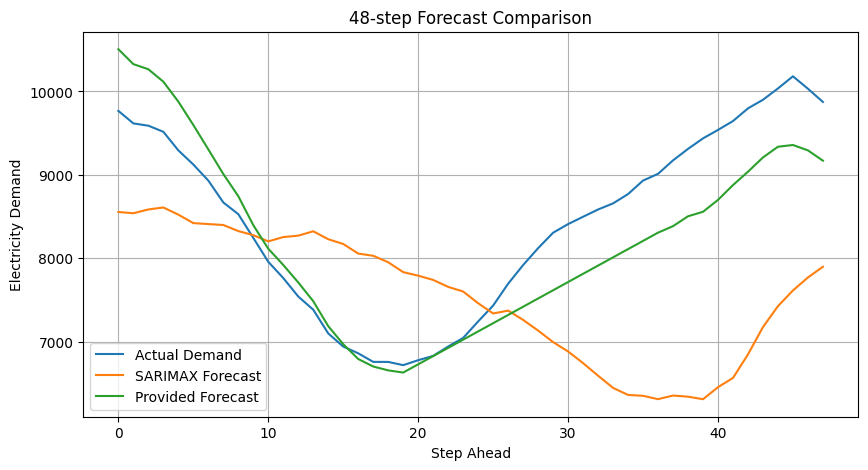

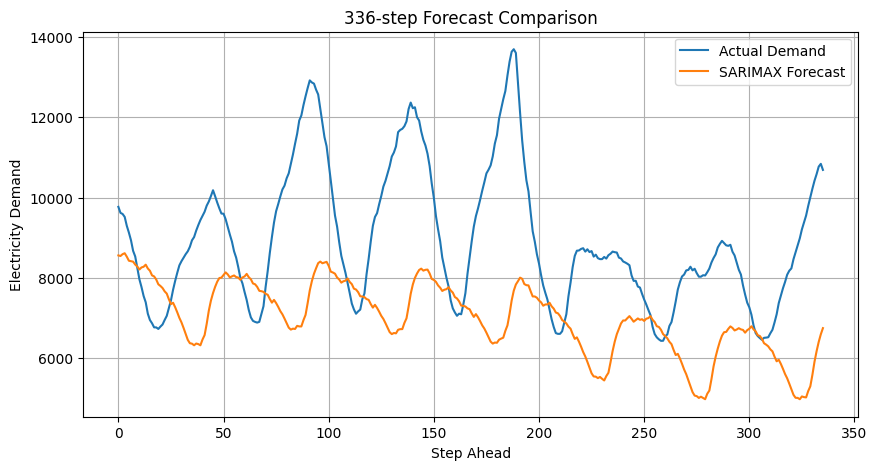

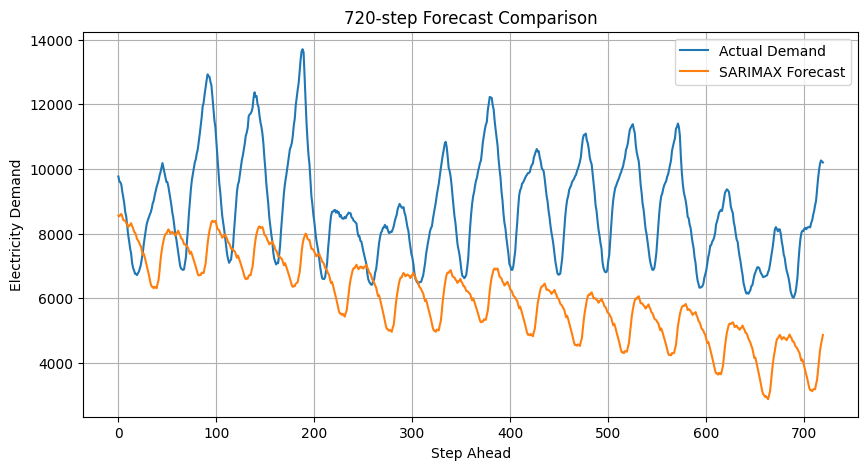

In [10]:
for h in horizons:
    y_actual, y_pred, rmse, mse = SARIMAX_results[h]

    if h == 48:
        provided = X_test.iloc[window_start:window_start + h]['FORECASTDEMAND']
    else:
        provided = None

    plot_forecast(
        y_actual,
        y_pred,
        provided,
        h,
        'SARIMAX Forecast'
    )

TheSARIMAX model performs reasonably well for short-term forecasting, particularly at the 48-step horizon, where it captures the general trend and daily pattern of electricity demand. However, it consistently underestimates peak demand and struggles to fully capture the amplitude of fluctuations.

As the forecast horizon increases, model performance deteriorates noticeably. At the 336-step and 720-step horizons, the forecasts show a downward bias and become less able to capture the cyclical behaviour and peak demand patterns present in the actual series. This indicates that forecast errors accumulate over time and the model has difficulty maintaining accuracy over longer horizons.

Overall, while the model provides a useful starting point, its limitations in capturing peak demand and longer-term behaviour highlight the need for model improvements.

## 8. Machine Learning Benchmark (Gradient Boosting)

### 8.1 Model Specification

To provide a benchmark against the statistical SARIMAX model, a gradient boosting regression model was implemented. Unlike SARIMAX, gradient boosting treats the forecasting task as a supervised machine learning regression problem, learning patterns from a set of engineered input features rather than modelling the time series structure directly.

The model uses a combination of lagged demand variables, weather information, and calendar-based features. In particular, lagged demand values are included to capture short-term and daily temporal dependencies, while temperature, temperature², and the provided forecast demand are included as exogenous predictors. Additional calendar features such as hour of day and day of week are used to help represent regular demand patterns.

The feature set used in the model is:

- lag 1
- lag 2
- lag 3
- lag 48
- lag 96
- rolling mean (6 steps)
- rolling mean (48 steps)
- temperature
- temperature²
- provided forecast demand
- hour of day
- day of week
- weekend indicator

This model is included as a machine learning benchmark to assess whether a more flexible nonlinear approach can better capture the complex patterns in electricity demand forecasting.

In [11]:
# -----------------------------------
# Prepare full dataset for feature engineering
# -----------------------------------
full_data = pd.concat([train, validation, test]).sort_index().copy()

# Nonlinear + calendar features
full_data['TEMP_SQUARED'] = full_data['TEMPERATURE'] ** 2
full_data['HOUR'] = full_data.index.hour
full_data['DAYOFWEEK'] = full_data.index.dayofweek
full_data['IS_WEEKEND'] = (full_data['DAYOFWEEK'] >= 5).astype(int)

# Lag features
full_data['lag_1'] = full_data['TOTALDEMAND'].shift(1)
full_data['lag_2'] = full_data['TOTALDEMAND'].shift(2)
full_data['lag_3'] = full_data['TOTALDEMAND'].shift(3)
full_data['lag_48'] = full_data['TOTALDEMAND'].shift(48)
full_data['lag_96'] = full_data['TOTALDEMAND'].shift(96)

# Rolling Averages
full_data['rolling_mean_6'] = full_data['TOTALDEMAND'].shift(1).rolling(6).mean()
full_data['rolling_mean_48'] = full_data['TOTALDEMAND'].shift(1).rolling(48).mean()

# Feature list
gb_features = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_48',
    'lag_96',
    'rolling_mean_6',
    'rolling_mean_48',
    'TEMPERATURE',
    'TEMP_SQUARED',
    'FORECASTDEMAND',
    'HOUR',
    'DAYOFWEEK',
    'IS_WEEKEND'
]

# Training data only (for fair comparison with SARIMAX)
train_gb = full_data.loc[train.index].dropna(subset=gb_features + ['TOTALDEMAND']).copy()

X_train_gb = train_gb[gb_features]
y_train_gb = train_gb['TOTALDEMAND']

# Fit gradient boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train_gb, y_train_gb)

GradientBoostingRegressor(learning_rate=0.03, max_depth=4, n_estimators=300,
                          random_state=42)

In [12]:
def run_gb_recursive_forecast(model, full_data, test, window_start, horizon, feature_cols):
    """
    Recursive multi-step forecast for Gradient Boosting model.
    """
    freq = pd.Timedelta(minutes=30)
    forecast_index = test.index[window_start:window_start + horizon]

    # Use all known actual demand up to the forecast origin
    history_end = forecast_index[0] - freq
    history = list(full_data.loc[:history_end, 'TOTALDEMAND'].values)

    preds = []

    for ts in forecast_index:
        temp = test.loc[ts, 'TEMPERATURE']
        forecast_demand = test.loc[ts, 'FORECASTDEMAND']

        row = pd.DataFrame([{
            'lag_1': history[-1],
            'lag_2': history[-2],
            'lag_3': history[-3],
            'lag_48': history[-48],
            'lag_96': history[-96],
            'rolling_mean_6': np.mean(history[-6:]),
            'rolling_mean_48': np.mean(history[-48:]),
            'TEMPERATURE': temp,
            'TEMP_SQUARED': temp ** 2,
            'FORECASTDEMAND': forecast_demand,
            'HOUR': ts.hour,
            'DAYOFWEEK': ts.dayofweek,
            'IS_WEEKEND': int(ts.dayofweek >= 5)
        }])

        yhat = model.predict(row[feature_cols])[0]
        preds.append(yhat)
        history.append(yhat)

    y_actual = test.iloc[window_start:window_start + horizon]['TOTALDEMAND']
    y_pred = pd.Series(preds, index=forecast_index)

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mse = mean_squared_error(y_actual, y_pred)

    return y_actual, y_pred, rmse, mse

### 8.2 Forecasting Results

The gradient boosting model is evaluated using the same forecast window and horizons as the SARIMAX model to ensure a fair comparison.

Forecasts are generated for:

• 48 steps (1 day)  
• 336 steps (7 days)  
• 720 steps (15 days)  

Comparison with the provided forecast is only conducted at the 48-step horizon, as longer horizons are not available.

A recursive forecasting approach is used so that predicted values are fed back into the lag features for future steps. Performance is assessed using RMSE and MSE, and visual comparison is used to evaluate how well the model captures demand patterns.

In [13]:
gb_results = {}

for h in horizons:
    y_actual, y_pred, rmse, mse = run_gb_recursive_forecast(
        gb_model, full_data, test, window_start, h, gb_features
    )

    # Store GB results
    gb_results[h] = (y_actual, y_pred, rmse, mse)

    print(f"[Gradient Boosting] Horizon {h}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MSE: {mse:.2f}")

    # Only compare to provided forecast for 48 steps
    if h == 48:
        provided = test.iloc[window_start:window_start + h]['FORECASTDEMAND']

        rmse_provided = np.sqrt(mean_squared_error(y_actual, provided))
        mse_provided = mean_squared_error(y_actual, provided)

        print(f"[Provided Forecast] Horizon {h}")
        print(f"RMSE: {rmse_provided:.2f}")
        print(f"MSE: {mse_provided:.2f}")

    print("-" * 30)

[Gradient Boosting] Horizon 48
RMSE: 509.68
MSE: 259771.40
[Provided Forecast] Horizon 48
RMSE: 540.96
MSE: 292637.50
------------------------------
[Gradient Boosting] Horizon 336
RMSE: 559.76
MSE: 313326.76
------------------------------
[Gradient Boosting] Horizon 720
RMSE: 500.85
MSE: 250848.94
------------------------------


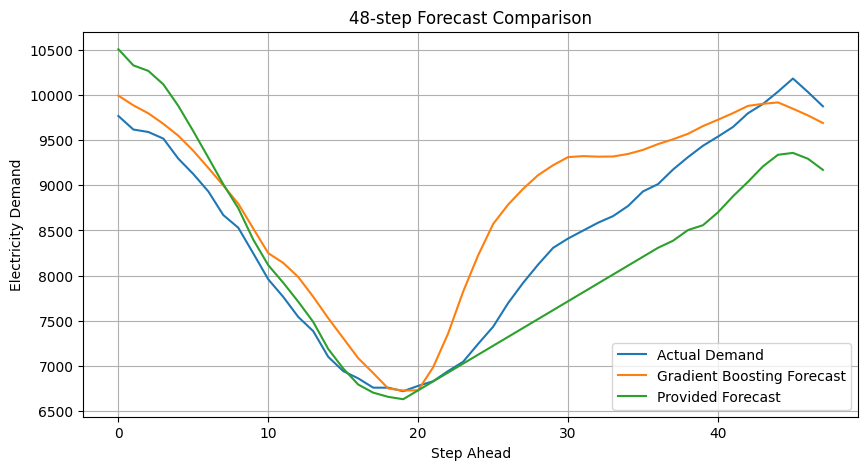

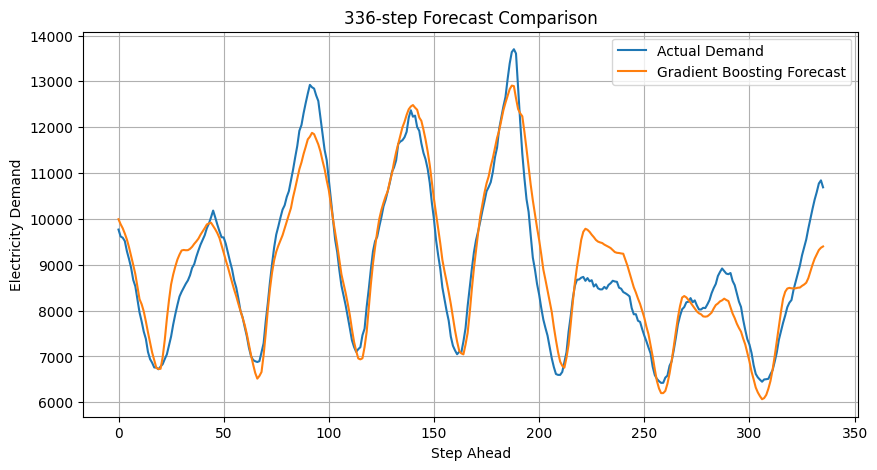

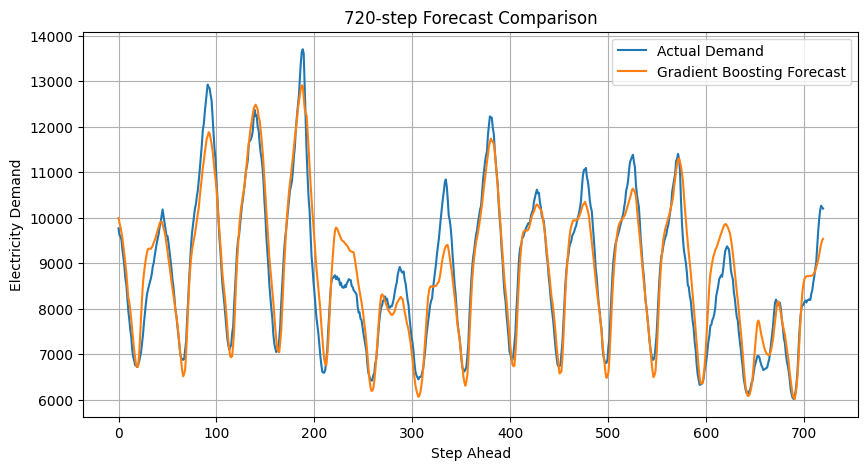

In [14]:
for h in horizons:
    y_actual, y_pred, rmse, mse = gb_results[h]

    if h == 48:
        provided = test.iloc[window_start:window_start + h]['FORECASTDEMAND']
    else:
        provided = None

    plot_forecast(
        y_actual,
        y_pred,
        provided,
        h,
        'Gradient Boosting Forecast'
    )

The gradient boosting model provides a machine learning benchmark against the SARIMAX model and demonstrates how a more flexible nonlinear approach performs on the same forecasting task.

At the 48-step horizon, the model achieved a substantially lower RMSE than the SARIMAX baseline and also outperformed the provided forecast. This suggests that the gradient boosting model is highly effective at capturing short-term demand behaviour, likely due to its ability to use lagged demand features, nonlinear temperature effects, and calendar-based predictors.

At the longer horizons of 336 and 720 steps, the model continued to outperform the SARIMAX baseline by a large margin. In particular, it did not exhibit the strong downward drift observed in the SARIMAX model and was much better able to capture peak demand and cyclical variation. However, at these longer horizons, the provided forecast was not available for meaningful comparison.

Overall, the gradient boosting model clearly outperformed the SARIMAX baseline and provided the strongest forecasting performance in this notebook. This provides a useful comparison between a classical statistical time series model and a more flexible machine learning approach for electricity demand forecasting.

## 9. Comparison of Models

This section compares the performance of the SARIMAX baseline and Gradient Boosting models across different forecasting horizons. Where available, results are also compared against the provided forecast.

At the 48-step horizon, Gradient Boosting clearly outperformed both the SARIMAX baseline and the provided forecast in terms of RMSE and MSE. The model also more closely followed the observed demand pattern, particularly around turning points and peak demand. This highlights the advantage of incorporating lagged demand features and nonlinear relationships when modelling short-term electricity demand.

At longer horizons (336 and 720 steps), Gradient Boosting continued to outperform the SARIMAX model by a large margin. While the SARIMAX model exhibited a strong downward drift and failed to capture peak demand, the Gradient Boosting model maintained realistic demand levels and better captured cyclical patterns. This suggests that the recursive machine learning approach is more robust for longer-term forecasting in this context.

However, it is important to note that the provided forecast is only available for short-term horizons, so comparisons at 336 and 720 steps are limited to the SARIMAX and Gradient Boosting models.

Overall, Gradient Boosting provided the strongest performance across all horizons, demonstrating that machine learning approaches can significantly outperform traditional statistical models for electricity demand forecasting, particularly when complex nonlinear patterns and temporal dependencies are present.

### 9.1 Numerical Comparison

In [15]:
# --- 48-step comparison (SARIMAX vs GB vs Provided) ---

h = 48

# SARIMAX
y_actual_s, y_pred_s, rmse_s, mse_s = SARIMAX_results[h]

# Gradient Boosting
y_actual_g, y_pred_g, rmse_g, mse_g = gb_results[h]

# Provided forecast
provided = test.iloc[window_start:window_start + h]['FORECASTDEMAND']
rmse_p = np.sqrt(mean_squared_error(y_actual_s, provided))
mse_p = mean_squared_error(y_actual_s, provided)

print("=== 48-step Comparison ===")
print(f"SARIMAX RMSE: {rmse_s:.2f} | MSE: {mse_s:.2f}")
print(f"Gradient Boosting RMSE: {rmse_g:.2f} | MSE: {mse_g:.2f}")
print(f"Provided Forecast RMSE: {rmse_p:.2f} | MSE: {mse_p:.2f}")

=== 48-step Comparison ===
SARIMAX RMSE: 1708.73 | MSE: 2919757.02
Gradient Boosting RMSE: 509.68 | MSE: 259771.40
Provided Forecast RMSE: 540.96 | MSE: 292637.50


###  9.2 Plot — 48 Step

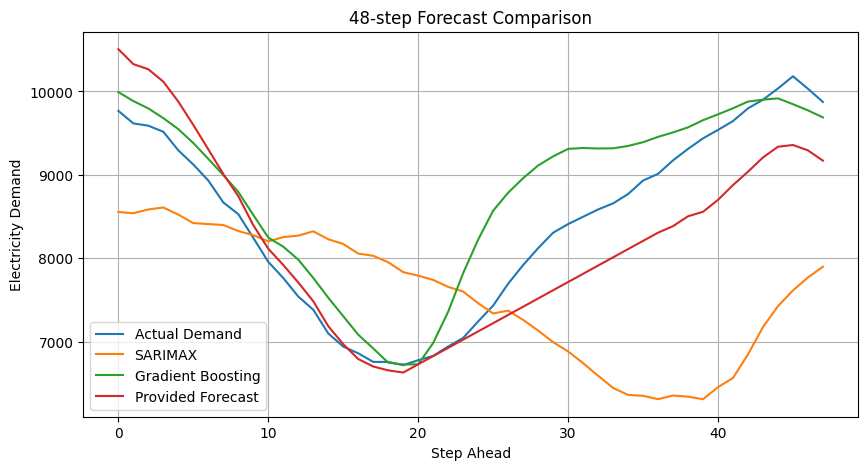

In [16]:
plt.figure(figsize=(10,5))

plt.plot(range(h), y_actual_s.values, label='Actual Demand')
plt.plot(range(h), y_pred_s.values, label='SARIMAX')
plt.plot(range(h), y_pred_g.values, label='Gradient Boosting')
plt.plot(range(h), provided.values, label='Provided Forecast')

plt.title('48-step Forecast Comparison')
plt.xlabel('Step Ahead')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid()
plt.show()

### 9.3 Numerical Comparison (336 & 720)

In [17]:
for h in [336, 720]:

    y_actual_s, y_pred_s, rmse_s, mse_s = SARIMAX_results[h]
    y_actual_g, y_pred_g, rmse_g, mse_g = gb_results[h]

    print(f"\n=== {h}-step Comparison ===")
    print(f"SARIMAX RMSE: {rmse_s:.2f} | MSE: {mse_s:.2f}")
    print(f"Gradient Boosting RMSE: {rmse_g:.2f} | MSE: {mse_g:.2f}")


=== 336-step Comparison ===
SARIMAX RMSE: 2657.43 | MSE: 7061948.54
Gradient Boosting RMSE: 559.76 | MSE: 313326.76

=== 720-step Comparison ===
SARIMAX RMSE: 3322.90 | MSE: 11041687.36
Gradient Boosting RMSE: 500.85 | MSE: 250848.94


### 9.4 Plots — 336 & 720

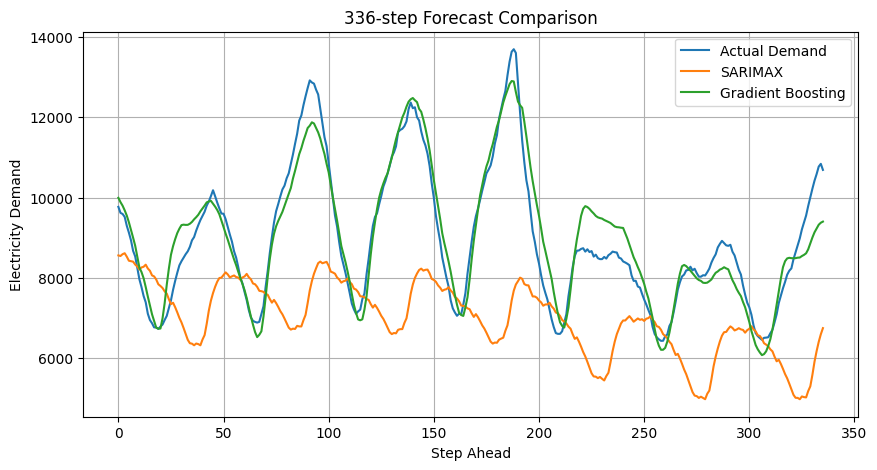

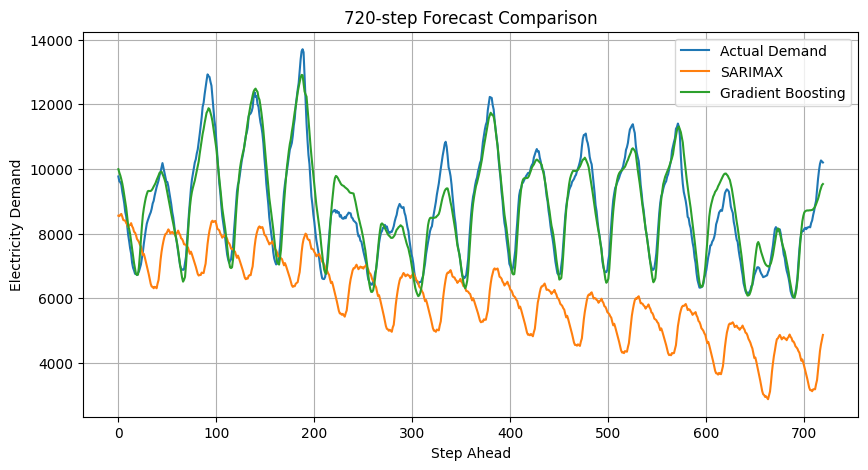

In [18]:
for h in [336, 720]:

    y_actual_s, y_pred_s, _, _ = SARIMAX_results[h]
    y_actual_g, y_pred_g, _, _ = gb_results[h]

    plt.figure(figsize=(10,5))

    plt.plot(range(h), y_actual_s.values, label='Actual Demand')
    plt.plot(range(h), y_pred_s.values, label='SARIMAX')
    plt.plot(range(h), y_pred_g.values, label='Gradient Boosting')

    plt.title(f'{h}-step Forecast Comparison')
    plt.xlabel('Step Ahead')
    plt.ylabel('Electricity Demand')
    plt.legend()
    plt.grid()
    plt.show()

This notebook developed and evaluated forecasting models for NSW electricity demand across multiple time horizons using both statistical and machine learning approaches.

The SARIMAX baseline model provided a simple and interpretable starting point, capturing general short-term trends but struggling with peak demand and longer-term behaviour. Model improvements such as the inclusion of a moving average term and nonlinear temperature feature led to only marginal gains, with performance still deteriorating significantly as the forecast horizon increased.

In contrast, the Gradient Boosting model demonstrated substantially stronger performance across all horizons. By incorporating lagged demand, nonlinear features, and calendar effects, it was able to better capture both short-term fluctuations and longer-term cyclical patterns. This resulted in significantly lower forecast errors and more realistic demand predictions compared to the SARIMAX models.

When compared to the provided forecast, Gradient Boosting achieved the best performance at the 48-step horizon, indicating that a well-engineered machine learning approach can outperform both traditional statistical models and existing benchmark forecasts in short-term prediction tasks.

Overall, the results highlight the limitations of SARIMAX models in handling complex, nonlinear electricity demand patterns, particularly over longer horizons. They also demonstrate the value of machine learning methods as more flexible and accurate alternatives for time series forecasting in real-world applications.